In [1]:
import os
os.chdir(r"C:\Users\wangy")
import pandas as pd
import numpy as np

**Preporcess before we start analysis**

In [57]:
df=pd.read_excel("diffusion(S3)/detail_diffusion.xlsx")
df0 = df.copy()  # your original diffusion (199,154 rows)

from pathlib import Path

# ---- Edit file paths ----
path_agent_job= Path("diffusion(S3)/agent_dep_job.csv")      # HR info
path_agent_wechat= Path("diffusion(S3)/agent_wechatnn.csv")   # WeChat mapping
path_topic = Path("batch_outputs(S2)/filtered2_results_clustered_all.xlsx")

# ---- Load ----
agent_job = pd.read_csv(path_agent_job)
wechatnn = pd.read_csv(path_agent_wechat)
topics = pd.read_excel(path_topic)

# --- Normalize keys (strip; keep NaN as NaN) ---
def norm_str(s):
    s = pd.Series(s, dtype="string").str.strip()
    return s.mask(s.eq(""))

df0["agent_name"]    = norm_str(df0["agent_name"])
df0["article_title"] = norm_str(df0["article_title"])
agent_job["agent_name"] = norm_str(agent_job.get("agent", agent_job.get("agent_name")))
agent_job = agent_job.rename(columns={"agent":"agent_name"})
wechatnn["agent_name"]  = norm_str(wechatnn["agent_name"])
topics["Title"]         = norm_str(topics["Title"])

# --- Topics: 1 row per Title, then map ---
topics_1 = (topics
            .drop_duplicates("Title", keep="first")
            .set_index("Title")["TopContentCluster"])
df0["TopContentCluster"] = df0["article_title"].map(topics_1)

# --- Jobs: 1 row per agent, then map columns one by one ---
jobs_1 = (agent_job
          .dropna(subset=["agent_dep","agent_job"])
          .loc[lambda d: d["agent_dep"].astype("string").str.strip().ne("")]
          .loc[lambda d: d["agent_job"].astype("string").str.strip().ne("")]
          .drop_duplicates("agent_name", keep="first")
          .set_index("agent_name"))

for col in ["agent_dep","agent_job"]:
    df0[col] = df0["agent_name"].map(jobs_1[col])

# --- WeChat names: collapse to a single row per agent, then map ---
def first_nonnull(s):
    s = s.dropna().astype("string").str.strip()
    s = s[s.ne("")]
    return s.iloc[0] if len(s) else np.nan

wechat_cols = [c for c in ["wechat_1","wechat_2","wechat_3"] if c in wechatnn.columns]
if wechat_cols:
    wechat_1 = (wechatnn.groupby("agent_name")[wechat_cols]
                .agg(first_nonnull))                       # 1 row per agent
else:
    # long form (agent_name, wechat_nn)
    wechatnn["wechat_nn"] = norm_str(wechatnn["wechat_nn"])
    pack = (wechatnn.dropna(subset=["wechat_nn"])
                    .groupby("agent_name")["wechat_nn"]
                    .apply(lambda s: pd.unique(s)[:3]).to_dict())
    def pick(i): 
        return {a: (arr[i] if len(arr)>i else np.nan) for a,arr in pack.items()}
    wechat_1 = pd.DataFrame({"wechat_1":pick(0), "wechat_2":pick(1), "wechat_3":pick(2)})

for col in ["wechat_1","wechat_2","wechat_3"]:
    if col in wechat_1.columns:
        df0[col] = df0["agent_name"].map(wechat_1[col])

In [58]:
# --- fix agent_job columns to ensure 'agent_name' is unique ---
aj = agent_job.copy()

# If both 'agent' and 'agent_name' exist, coalesce then drop 'agent'
if 'agent' in aj.columns and 'agent_name' in aj.columns:
    aj['agent_name'] = aj['agent_name'].fillna(aj['agent'])
    aj = aj.drop(columns=['agent'])
elif 'agent' in aj.columns:
    aj = aj.rename(columns={'agent':'agent_name'})

# Drop any duplicate columns that share the same header
if aj.columns.duplicated().any():
    dup_cols = aj.columns[aj.columns.duplicated()]
    print("Dropping duplicate columns from agent_job:", list(dup_cols))
    aj = aj.loc[:, ~aj.columns.duplicated()]

print("Row count (should equal original df):", len(merged), "vs", len(df))

Dropping duplicate columns from agent_job: ['agent_name']
Row count (should equal original df): 201014 vs 199154


In [59]:
merged = (df
  .merge(topics.drop_duplicates("Title")[["Title","TopContentCluster"]],
         left_on="article_title", right_on="Title", how="left", validate="m:1")
  .merge(aj.drop_duplicates("agent_name")[["agent_name","agent_dep","agent_job"]],
         on="agent_name", how="left", validate="m:1")
  .merge(wechat_1.reset_index(),  # from the collapse step above
         on="agent_name", how="left", validate="m:1")
)

In [60]:
len(merged)

199154

In [61]:
merged.head()

,detail_index,article_title,agent_name,reader_wechat_nn,reader_layer,reader_address,reader_gender,reader_time,reader_stay,reader_share2moment,reader_share2friend,reader_read,network_parent,Title,TopContentCluster,agent_dep,agent_job,wechat_1,wechat_2,wechat_3
0,1350,#名匠出品 必属精品#,赵林,赵·国际城G组团·负责专员,1,贵州贵阳,1,2017-09-28 05:36:14,0,0,0,3,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN
1,1351,#名匠出品 必属精品#,赵林,完美love,1,上海,0,2017-08-23 05:54:00,0,0,0,1,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN
2,1352,#名匠出品 必属精品#,赵林,琪琪,1,贵州贵阳,0,2017-08-22 21:55:05,30,0,0,1,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN
3,1353,#名匠出品 必属精品#,赵林,陈俊东-名匠装饰-家装顾问,1,贵州贵阳,1,2017-08-23 05:55:17,0,0,0,1,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN
4,1354,#名匠出品 必属精品#,赵林,丹,1,中国 贵州 贵阳,0,2017-08-23 05:56:55,0,0,0,1,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN


**Update the reader_layer since some are agents that use their own account to read and share the article.**

In [30]:
# import pandas as pd
# import numpy as np

# # Start from your merged dataframe
# df = merged.copy()

# # --- 1) Trim spaces but DO NOT turn NaNs into strings ---
# def strip_preserve_na(x):
#     if pd.isna(x):
#         return x
#     return str(x).strip()

# cols_to_strip = ["reader_wechat_nn", "network_parent", "wechat_1", "wechat_2", "wechat_3"]
# for c in cols_to_strip:
#     if c in df.columns:
#         df[c] = df[c].apply(strip_preserve_na)

# # --- 2) Build masks for membership in the agent's wechat accounts ---
# wechat_cols = ["wechat_1", "wechat_2", "wechat_3"]

# # reader matches any non-null wechat_i
# cond_reader = False
# for wc in wechat_cols:
#     cond_reader = cond_reader | (df[wc].notna() & (df["reader_wechat_nn"] == df[wc]))

# # parent is considered only if it's not missing and not the literal "nan"
# valid_parent = df["network_parent"].notna() & (df["network_parent"].str.lower() != "nan")

# cond_parent = False
# for wc in wechat_cols:
#     cond_parent = cond_parent | (valid_parent & df[wc].notna() & (df["network_parent"] == df[wc]))

# # --- 3) Apply your IF / ELIF / ELSE logic (subtract at most once) ---
# df["reader_layer_original"] = df["reader_layer"]

# subtract_flag = cond_reader | (~cond_reader & cond_parent)   # IF reader else IF parent else 0
# df["reader_layer"] = (df["reader_layer"] - subtract_flag.astype(int)).clip(lower=0)

# # Optional: audit reason
# df["adjust_reason"] = np.select(
#     [cond_reader, (~cond_reader & cond_parent)],
#     ["reader_is_agent_wechat", "parent_is_agent_wechat"],
#     default=None
# )

In [62]:
import networkx as nx
nx.__version__

'3.5'

In [63]:
import pandas as pd
import numpy as np
import networkx as nx

df = merged.copy()

# 1) Light cleanup (trim; keep real NaNs)
def _strip(x):
    return x if pd.isna(x) else str(x).strip()

for c in ["reader_wechat_nn","network_parent","wechat_1","wechat_2","wechat_3"]:
    if c in df.columns:
        df[c] = df[c].apply(_strip)

# Ensure numeric layer for fallback use
df["reader_layer"] = pd.to_numeric(df["reader_layer"], errors="coerce").fillna(0).astype(int)

# 2) Canonicalize node IDs: map agent aliases and layer==0 to the agent node
wechat_cols = [c for c in ["wechat_1","wechat_2","wechat_3"] if c in df.columns]

def _alias_set(row):
    return {row[c] for c in wechat_cols if pd.notna(row.get(c))}

def canon_reader(row):
    aliases = _alias_set(row)
    # self-read (layer 0) or reader is an alias → treat as the agent node
    if row["reader_layer"] == 0 or row["reader_wechat_nn"] in aliases:
        return row["agent_name"]
    return row["reader_wechat_nn"]

def canon_parent(row):
    if pd.isna(row.get("network_parent")):
        return np.nan
    aliases = _alias_set(row)
    # alias parent → agent
    if row["network_parent"] in aliases:
        return row["agent_name"]
    return row["network_parent"]

df["node_id"]   = df.apply(canon_reader, axis=1)
df["parent_id"] = df.apply(canon_parent,  axis=1)

# 3) Build observed graph per (agent, article) and compute BFS distance from agent
def compute_correct_layer(frame: pd.DataFrame) -> pd.DataFrame:
    g = frame.copy()
    agent = g["agent_name"].iloc[0]

    # Directed graph from observed edges only
    G = nx.DiGraph()
    G.add_node(agent)
    G.add_nodes_from(g["node_id"].astype(str))

    # agent → node for recorded layer==1
    e1 = [(agent, nid) for nid in g.loc[g["reader_layer"]==1, "node_id"].astype(str)]

    # parent → child for recorded layer>=2 (parent_id present)
    sub = g.loc[g["reader_layer"]>=2, ["parent_id","node_id"]].dropna(subset=["parent_id"])
    e2 = list(zip(sub["parent_id"].astype(str), sub["node_id"].astype(str)))

    G.add_edges_from(e1 + e2)

    # Undirected distances for layers
    UG = G.to_undirected()

    # Distances dict (agent=0). If agent isolated, at least {agent:0}.
    dist = nx.single_source_shortest_path_length(UG, agent) if agent in UG else {agent: 0}

    # Map distances; fill unreachable with original recorded layer; cast to int safely
    nid = g["node_id"].astype(str)
    mapped = nid.map(dist)                          # may contain NaN if unreachable
    fallback = g["reader_layer"]                    # already int from earlier
    g["correct_layer"] = mapped.fillna(fallback).astype(int)

    return g

df = (
    df.groupby(["agent_name","article_title"], sort=False, group_keys=False)
      .apply(compute_correct_layer)
      .reset_index(drop=True)
)

print("✅ Added column: correct_layer (BFS distance from agent on observed graph).")


C:\Users\wangy\AppData\Local\Temp\ipykernel_30804\1428748857.py:78: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_correct_layer)


✅ Added column: correct_layer (BFS distance from agent on observed graph).


In [64]:
df.head()

,detail_index,article_title,agent_name,reader_wechat_nn,reader_layer,reader_address,reader_gender,reader_time,reader_stay,reader_share2moment,...,Title,TopContentCluster,agent_dep,agent_job,wechat_1,wechat_2,wechat_3,node_id,parent_id,correct_layer
0,1350,#名匠出品 必属精品#,赵林,赵·国际城G组团·负责专员,1,贵州贵阳,1,2017-09-28 05:36:14,0,0,...,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,赵林,NaN,0
1,1351,#名匠出品 必属精品#,赵林,完美love,1,上海,0,2017-08-23 05:54:00,0,0,...,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,完美love,NaN,1
2,1352,#名匠出品 必属精品#,赵林,琪琪,1,贵州贵阳,0,2017-08-22 21:55:05,30,0,...,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,琪琪,NaN,1
3,1353,#名匠出品 必属精品#,赵林,陈俊东-名匠装饰-家装顾问,1,贵州贵阳,1,2017-08-23 05:55:17,0,0,...,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,陈俊东-名匠装饰-家装顾问,NaN,1
4,1354,#名匠出品 必属精品#,赵林,丹,1,中国 贵州 贵阳,0,2017-08-23 05:56:55,0,0,...,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,丹,NaN,1


In [65]:
df.shape

(199154, 23)

In [66]:
df.query("agent_name == '赵林' and article_title.str.contains('#名匠出品 必属精品#')")[["article_title", "agent_name", "reader_wechat_nn", "network_parent", "reader_layer", "correct_layer"]
]

,article_title,agent_name,reader_wechat_nn,network_parent,reader_layer,correct_layer
0,#名匠出品 必属精品#,赵林,赵·国际城G组团·负责专员,NaN,1,0
1,#名匠出品 必属精品#,赵林,完美love,NaN,1,1
2,#名匠出品 必属精品#,赵林,琪琪,NaN,1,1
3,#名匠出品 必属精品#,赵林,陈俊东-名匠装饰-家装顾问,NaN,1,1
4,#名匠出品 必属精品#,赵林,丹,NaN,1,1
5,#名匠出品 必属精品#,赵林,刘行恩·名匠装饰18373832827,NaN,1,1
6,#名匠出品 必属精品#,赵林,??MJ·陆文俊,NaN,1,1
7,#名匠出品 必属精品#,赵林,邓春.名匠装饰.主任设计师,NaN,1,1
8,#名匠出品 必属精品#,赵林,李扬-名匠装饰-家装顾问,NaN,1,1
9,#名匠出品 必属精品#,赵林,金牌标榜张平18786622376,NaN,1,1


In [67]:
df.query("agent_name == '吴梦娇' and article_title.str.contains('110平方')")[["article_title", "agent_name", "reader_wechat_nn", "network_parent", "reader_layer", "correct_layer"]
]

,article_title,agent_name,reader_wechat_nn,network_parent,reader_layer,correct_layer
18,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,MJ～吴梦娇,NaN,1,0
19,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,海,MJ～吴梦娇,2,1
20,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,申瑞特 黄俊博,MJ～吴梦娇,2,1
21,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,赵猛,MJ～吴梦娇,2,1
22,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,莲,MJ～吴梦娇,2,1
23,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,流水知音,MJ～吴梦娇,2,1


In [68]:
df.query("agent_name == '何纯勇' and article_title.str.contains('10大主流')")[["article_title", "agent_name", "reader_wechat_nn", "network_parent", "reader_layer", "correct_layer"]
]

,article_title,agent_name,reader_wechat_nn,network_parent,reader_layer,correct_layer
411,10大主流装修风格详解，你喜欢哪个范？,何纯勇,名匠装饰·何东,NaN,1,0
412,10大主流装修风格详解，你喜欢哪个范？,何纯勇,MJ~左都美,NaN,1,1
413,10大主流装修风格详解，你喜欢哪个范？,何纯勇,【千里湖山】李进伟,NaN,1,1
414,10大主流装修风格详解，你喜欢哪个范？,何纯勇,加油@自己,NaN,1,1
415,10大主流装修风格详解，你喜欢哪个范？,何纯勇,??特困户??,NaN,1,1
416,10大主流装修风格详解，你喜欢哪个范？,何纯勇,ping-p,NaN,1,1
417,10大主流装修风格详解，你喜欢哪个范？,何纯勇,O(∩_∩)O,NaN,1,1
418,10大主流装修风格详解，你喜欢哪个范？,何纯勇,不负好时光,NaN,1,1
419,10大主流装修风格详解，你喜欢哪个范？,何纯勇,陈琳,NaN,1,1
420,10大主流装修风格详解，你喜欢哪个范？,何纯勇,MJ-设计师彭黎君,NaN,1,1


In [107]:
df.query("agent_name == '龙爱香' and article_title.str.contains('名匠心，设计情')")[["article_title", "agent_name", "reader_wechat_nn", "network_parent", "reader_layer", "correct_layer"]]

,article_title,agent_name,reader_wechat_nn,network_parent,reader_layer,correct_layer
185307,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,MJ-蔡燕,NaN,1,1
185308,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,AO名匠家装顾问杨松13627303816,NaN,1,1
185309,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,A0名匠装饰聂新玉15842892586,NaN,1,1
185310,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,A0名匠装饰区域经理龙爱香,NaN,1,0
185311,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,邓旭,NaN,1,1
185312,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,年年有鱼,NaN,1,1
186991,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,何多多,A.名匠家装 李栗13607309830,2,2
186992,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,小太阳??,A.名匠家装 李栗13607309830,2,2
186993,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,MJ家装顾问闵雪,A.名匠家装 李栗13607309830,2,2
186994,【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动,龙爱香,阿莲,A.名匠家装 李栗13607309830,2,2


In [69]:
df['correct_layer'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7, 10,  9, 11,  8, 12, 13, 14, 15, 16,
       17, 19, 21, 18, 22, 23])

In [70]:
df.to_excel("diffusion(S3)/diffusion_corrected_layers.xlsx", index=False)

In [71]:
df['reader_gender'].unique()

array([1, 0])

In [72]:
import pandas as pd

df = pd.read_excel("diffusion(S3)/diffusion_corrected_layers.xlsx")
unique_agents = df['agent_name'].dropna().unique()
print(len(unique_agents))
unique_agents_df = pd.DataFrame(unique_agents, columns=['agent_name'])
unique_agents_df.to_excel("diffusion(S3)/unique_agents.xlsx", index=False)

print(f"✅ Saved {len(unique_agents_df)} unique agents to unique_agents.xlsx")

592
✅ Saved 592 unique agents to unique_agents.xlsx


In [73]:
df.shape

(199154, 23)

In [129]:
import pandas as pd
from pathlib import Path
path_topic = Path("batch_outputs(S2)/filtered2_results_clustered_all.xlsx")
topics = pd.read_excel(path_topic)

agents = pd.read_excel("diffusion(S3)/unique_agentsgender.xlsx")  # contains agent_name, gender
diffusion = pd.read_excel("diffusion(S3)/diffusion_corrected_layers.xlsx")

# Step 2: Merge on agent_name
merged = diffusion.merge(agents, on="agent_name", how="left")
merged= merged.drop(columns=["TopContentCluster"])

In [130]:
merged.shape

(199154, 23)

In [132]:
merged = merged.merge(
    topics[["Title", "家居设计与装修(Content)", "房地产与建筑(Content)", "活动与促销(Content)", 
            "品牌与市场推广(Content)", "生活方式与文化(Content)", "客户服务与管理(Content)"]],
    on= "Title",
    how="left"
)

In [133]:
merged.shape

(199154, 29)

In [134]:
# Step 3: Save to a new Excel file
merged.to_excel("diffusion(S3)/diffusion_genderTopicvector.xlsx", index=False)

print(f"✅ Merged dataset saved as diffusion_with_gender.xlsx with shape {merged.shape}")

✅ Merged dataset saved as diffusion_with_gender.xlsx with shape (199154, 29)


In [146]:
import pandas as pd
import numpy as np
import networkx as nx

# 0) Load data
DATA_PATH = "diffusion(S3)/diffusion_genderTopicvector.xlsx"
data = pd.read_excel(DATA_PATH)

In [147]:
# --- Step 1: Build mapping only from agents that have a layer 0 (self row) ---
layer0 = (
    data.loc[data["correct_layer"] == 0, ["agent_name", "reader_gender"]]
        .dropna(subset=["reader_gender"])
        .drop_duplicates("agent_name", keep="first")
)

map_dict = dict(zip(layer0["agent_name"], layer0["reader_gender"]))

# --- Step 2: Overwrite agent_gender only for those with layer 0 ---
has_layer0 = data["agent_name"].isin(map_dict.keys())
data.loc[has_layer0, "agent_gender"] = data.loc[has_layer0, "agent_name"].map(map_dict)

# --- Step 3: Keep the existing agent_gender for others (no layer 0) ---
# → Nothing else needed, because the map only touched has_layer0 rows

# --- Optional diagnostic ---
print("Agents with layer0 used to overwrite:", len(map_dict))
print("Rows overwritten:", has_layer0.sum())
print("Remaining NaNs in agent_gender:", data["agent_gender"].isna().sum())


Agents with layer0 used to overwrite: 551
Rows overwritten: 193474
Remaining NaNs in agent_gender: 0


In [148]:
data["agent_gender"].unique()

array([1, 0])

In [149]:
# =========================
# 2) Convenience columns
# =========================
data["duration_seconds"] = data["reader_stay"] * 15

# Keep your original reshare logic: treat exactly 1 as a reshare
data["reshare_flag"] = (
    (data["reader_share2moment"].astype(int) == 1) |
    (data["reader_share2friend"].astype(int) == 1)
)

data["cascade_key"] = list(zip(data["agent_name"], data["article_title"]))
grp = data.groupby("cascade_key", sort=False)

In [150]:
# =========================
# 3) Vectorized metrics
# =========================
first_layer_width  = grp["correct_layer"].apply(lambda s: (s == 1).sum()).rename("first_layer_width")
second_layer_width = grp["correct_layer"].apply(lambda s: (s == 2).sum()).rename("second_layer_width")
depth              = grp["correct_layer"].max().astype(int).rename("depth")

# Audience-only reshare % (exclude layer 0; 1 row per person per cascade)
aud = data.loc[data["correct_layer"] >= 1].copy()
person = (
    aud.groupby(["cascade_key", "reader_wechat_nn"], as_index=False)
       .agg(reshared=("reshare_flag", "max"))
)
reshare_pct = (
    person.groupby("cascade_key", sort=False)["reshared"]
          .mean()
          .rename("reshare_pct")
)

# Durations
duration_mean = grp["duration_seconds"].mean().rename("duration_mean_s")
duration_var  = grp["duration_seconds"].var(ddof=1).rename("duration_var_s2")

# Gender percentage (overall, includes agent)
gender_counts_all = grp["reader_gender"].value_counts().unstack(fill_value=0)
gender_pct_all = (gender_counts_all.T / gender_counts_all.sum(axis=1)).T
gender_pct_all.columns = [f"gender_pct_all_{c}" for c in gender_pct_all.columns]


# --- Audience-only gender percentage (exclude layer 0) ---
# 1) Build the full index of all cascades
all_keys = pd.Index(grp.size().index, name="cascade_key")

# 2) Group only audience rows
aud = data.loc[data["correct_layer"] >= 1, ["cascade_key", "reader_gender"]].copy()

aud_gender_counts = (
    aud.groupby("cascade_key")["reader_gender"]
       .value_counts(dropna=False)
       .unstack(fill_value=0)
    # 3) Ensure cascades with no readers are included (rows of all zeros)
    .reindex(all_keys, fill_value=0)
)

# 4) Convert counts to percentages; rows with zero readers -> 0s
den = aud_gender_counts.sum(axis=1)
aud_gender_pct = aud_gender_counts.div(den.replace(0, 1), axis=0)  # avoid divide-by-zero
aud_gender_pct[den == 0] = 0

# 5) Rename columns
aud_gender_pct.columns = [f"gender_pct_aud_{c}" for c in aud_gender_pct.columns]


In [151]:
# =========================
# 4) Graph metrics
#   - centralization
#   - wiener index
#   - structural virality
#   - gender assortativity (custom smoothed denominator: +1)
#   - agent/out-degree centralities
def graph_metrics(frame: pd.DataFrame) -> pd.Series:
    agent = frame["agent_name"].iloc[0]

    # Directed cascade graph
    G = nx.DiGraph()
    G.add_node(agent)
    readers = frame["reader_wechat_nn"].astype(str)
    G.add_nodes_from(readers)

    # agent -> reader for layer 1
    e1 = [(agent, r) for r in frame.loc[frame["correct_layer"] == 1, "reader_wechat_nn"].astype(str)]

    # parent -> child for deeper layers
    sub2 = frame.loc[frame["correct_layer"] >= 2, ["network_parent", "reader_wechat_nn"]]
    e2 = list(zip(sub2["network_parent"].astype(str), sub2["reader_wechat_nn"].astype(str)))

    G.add_edges_from(e1 + e2)

    n_dir = G.number_of_nodes()
    m_dir = G.number_of_edges()

    # Agent node out-degree centrality (0..1)
    agent_deg_cent = nx.out_degree_centrality(G).get(agent, 0.0)

    # Average out-degree centrality = m / (n*(n - 1))
    avg_out_deg_cent = 0.0 if n_dir < 2 else m_dir / (n_dir * (n_dir - 1))

    # Freeman out-degree centralization (graph-level)
    out_deg = dict(G.out_degree())
    if n_dir <= 2:
        centralization = 0.0
    else:
        max_deg = max(out_deg.values()) if out_deg else 0
        numer = sum(max_deg - d for d in out_deg.values())
        denom = (n_dir - 1) * (n_dir - 2)
        centralization = numer / denom if denom > 0 else 0.0

    # Undirected for distances/assortativity
    UG = G.to_undirected()
    if UG.number_of_edges() == 0:
        return pd.Series({
        "centrality": centralization,
        "wiener_index": 0.0,
        "structural_virality": np.nan,
        "gender_assortativity": 0.0,   # <- set 0 when no edges/readers
        "agent_deg_centrality": agent_deg_cent,
        "avg_out_degree_centrality": avg_out_deg_cent
    })

    # Largest connected component
    H = UG.subgraph(max(nx.connected_components(UG), key=len)).copy()

    # Wiener index & structural virality
    spl = dict(nx.all_pairs_shortest_path_length(H))
    nodes = list(H.nodes())
    nn = len(nodes)
    wsum = sum(spl[n1][n2] for i, n1 in enumerate(nodes) for n2 in nodes[i+1:])
    wiener = float(wsum)
    structural_virality = (2.0 * wiener) / (nn * (nn - 1)) if nn >= 2 else np.nan

    # ---- Robust agent gender lookup ----
    # Prefer reader_gender on layer 0; if missing, fall back to agent_gender column; else NaN
    # ---- Custom gender assortativity with smoothed denominator (+1) ----
# Agent gender: prefer layer-0 reader_gender; else use agent_gender column (already normalized to 0/1)
    s0 = frame.loc[frame["correct_layer"] == 0, "reader_gender"].dropna()
    agent_gender = int(s0.iloc[0]) if not s0.empty else int(frame["agent_gender"].dropna().iloc[0])

# Node genders from normalized columns
    node_gender = {str(r): (int(g) if not pd.isna(g) else np.nan)
                   for r, g in zip(frame["reader_wechat_nn"].astype(str), frame["reader_gender"])}
    node_gender[str(agent)] = agent_gender
    nx.set_node_attributes(H, node_gender, "gender")

    def _valid(g):
        return (not pd.isna(g)) and (g in (0, 1))

    mm = ff = mf = 0
    for u, v in H.edges():
        gu = H.nodes[u].get("gender")
        gv = H.nodes[v].get("gender")
        if not (_valid(gu) and _valid(gv)):
            continue
        if (gu == 1) and (gv == 1):
            mm += 1
        elif (gu == 0) and (gv == 0):
            ff += 1
        else:
            mf += 1
    m = mm + ff + mf
    if m == 0:
        assort_smooth = 0.0   # force 0 when no usable gendered edges
    else:
        e_mm, e_ff, e_mf = mm/m, ff/m, mf/m
        p_same = e_mm + e_ff
        a_m = e_mm + 0.5*e_mf
        a_f = e_ff + 0.5*e_mf
        expected_same = a_m**2 + a_f**2
        denom = (1.0 - expected_same) + 1.0  # your +1 smoothing
        numer = (p_same - expected_same)
        assort_smooth = numer / denom


    return pd.Series({
        "centrality": centralization,
        "wiener_index": wiener,
        "structural_virality": structural_virality,
        "gender_assortativity": assort_smooth,
        "agent_deg_centrality": agent_deg_cent,
        "avg_out_degree_centrality": avg_out_deg_cent
    })


graph_df = grp.apply(graph_metrics)

C:\Users\wangy\AppData\Local\Temp\ipykernel_30804\458562229.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  graph_df = grp.apply(graph_metrics)


In [152]:
# =========================
# 5) Assemble & save
# =========================
out = pd.concat(
    [first_layer_width, second_layer_width, depth, reshare_pct,
     graph_df, duration_mean, duration_var],
    axis=1
).join(gender_pct_all, how="left") \
 .join(aud_gender_pct, how="left")

# Restore keys as columns
out[["agent_name", "article_title"]] = pd.DataFrame(out.index.tolist(), index=out.index)
out = out.reset_index(drop=True)

# Final column order
cols = [
    "agent_name", "article_title", "article_topic",
    "first_layer_width", "second_layer_width", "depth",
    "reshare_pct", "centrality", "wiener_index", "structural_virality",
    "gender_assortativity", "agent_deg_centrality", "avg_out_degree_centrality",
    "duration_mean_s", "duration_var_s2"
] + [c for c in out.columns if c.startswith("gender_pct_all_")] \
  + [c for c in out.columns if c.startswith("gender_pct_aud_")]

out = out.reindex(columns=[c for c in cols if c in out.columns])

In [153]:
out.head()

,agent_name,article_title,first_layer_width,second_layer_width,depth,reshare_pct,centrality,wiener_index,structural_virality,gender_assortativity,agent_deg_centrality,avg_out_degree_centrality,duration_mean_s,duration_var_s2,gender_pct_all_1,gender_pct_all_0,gender_pct_aud_0,gender_pct_aud_1
0,赵林,#名匠出品 必属精品#,17,0,1,0.000000,1.000000,289.0,1.888889,-0.063885,0.944444,0.049708,150.000000,1.191176e+05,0.611111,0.388889,0.411765,0.588235
1,吴梦娇,#名匠出品 必属精品#[玫瑰] 面积：110平方,5,0,1,0.000000,1.000000,25.0,1.666667,-0.216216,0.833333,0.119048,375.000000,3.375000e+04,0.666667,0.333333,0.200000,0.800000
2,周志刚,108㎡优雅灰色装饰，考古、机械爱好者的家，真酷！,60,78,2,0.028986,0.426708,6652.0,2.754451,-0.043478,0.428571,0.013883,1105.714286,2.531795e+07,0.671429,0.328571,0.333333,0.666667
3,龙海,10大主流装修风格详解，你喜欢哪个范？,31,46,3,0.051948,0.368631,8618.0,2.869797,0.005486,0.371795,0.012496,867.073171,1.003902e+06,0.390244,0.609756,0.625000,0.375000
4,吴灿,10大主流装修风格详解，你喜欢哪个范？,88,24,3,0.050505,0.752525,11817.0,2.387273,-0.064557,0.747475,0.010000,939.823009,1.220632e+06,0.407080,0.592920,0.592920,0.407080


In [159]:
out_path = "diffusion(S3)/analyzed1_diffusion.xlsx"
out.to_excel(out_path, index=False)

In [155]:
missing_gender_agents = data.loc[data["agent_gender"].isna(), "agent_name"].unique()
print("Agents with missing gender:", missing_gender_agents)
print("Count:", len(missing_gender_agents))

Agents with missing gender: []
Count: 0


In [156]:
out["gender_assortativity"].isna().sum()

np.int64(0)

In [180]:
data = pd.read_excel("diffusion(S3)/analyzed1_diffusion.xlsx")

In [181]:
# Example: load only the sheet named "metrics"
df = pd.read_excel("diffusion(S3)/agentposition_categories.xlsx", sheet_name="作者统计")
df.head()

,agent_id,agent_name,count_read,sum_read,avg_read,max_layer,avg_layer,max_stay,avg_stay,sum_stay,man_ratio,agent_dep,agent_job,JobCategory,agent_group_id,agent_district,Unnamed: 16
0,2,欧发生,1467,2459,1.6762,15,4.7982,2730,35.1943,51630,0.4806,常德区常德桥南店设计部,店总经理,1,7,常德,NaN
1,3,黄蓉,2285,2652,1.1606,5,1.9781,3630,72.0788,164700,0.3195,城东店网络部长沙区,NaN,4,143,长沙,NaN
2,4,龙海,3514,4146,1.1799,5,1.7208,9240,72.0205,253080,0.4314,省府店网络部长沙区,网络主管,4,128,长沙,NaN
3,5,吴灿,5587,6823,1.2212,16,2.9331,4380,65.8905,368130,0.4016,省府店网络部长沙区,网销家装顾问,4,128,长沙,NaN
4,7,彭娟,1967,2332,1.1856,6,2.0010,6390,64.1027,126090,0.4311,梅溪湖店网络部长沙区,网销家装顾问,4,111,长沙,NaN


In [182]:
data = data.merge(
    topics[["Title", "家居设计与装修(Content)", "房地产与建筑(Content)", "活动与促销(Content)", 
            "品牌与市场推广(Content)", "生活方式与文化(Content)", "客户服务与管理(Content)"]],
    left_on = "article_title", right_on= "Title",
    how="left"
)

In [183]:
data.shape

(6557, 25)

In [184]:
data = data.merge(
    df[["agent_name", "JobCategory"]],
    on= "agent_name",
    how="left"
)

In [185]:
data.shape

(6557, 26)

In [186]:
cols = [
    "agent_name", "article_title", "first_layer_width", "second_layer_width", "depth",
    "reshare_pct", "centrality", "wiener_index", "structural_virality", "gender_assortativity",
    "gender_pct_aud_0", "gender_pct_aud_1"
]

# Count NaN values per column
nan_counts = data[cols].isna().sum()

print("NaN counts per column:")
print(nan_counts)


NaN counts per column:
agent_name                0
article_title             0
first_layer_width         0
second_layer_width        0
depth                     0
reshare_pct             754
centrality                0
wiener_index              0
structural_virality     754
gender_assortativity      0
gender_pct_aud_0          0
gender_pct_aud_1          0
dtype: int64


In [187]:
data["reshare_pct"] = data["reshare_pct"].fillna(0)
data["structural_virality"] = data["structural_virality"].fillna(0)

In [188]:
data["JobCategory"].unique()

array([ 3.,  4., nan,  1.,  2.])

In [189]:
nan_rows = data[data["JobCategory"].isna()]
print(nan_rows.shape)
nan_rows.head()

(138, 26)


,agent_name,article_title,first_layer_width,second_layer_width,depth,reshare_pct,centrality,wiener_index,structural_virality,gender_assortativity,...,gender_pct_aud_0,gender_pct_aud_1,Title,家居设计与装修(Content),房地产与建筑(Content),活动与促销(Content),品牌与市场推广(Content),生活方式与文化(Content),客户服务与管理(Content),JobCategory
18,李杰,10大主流装修风格详解，你喜欢哪个范？,13,12,2,0.080000,0.501538,769,2.366154,-0.142698,...,0.640000,0.360000,10大主流装修风格详解，你喜欢哪个范？,90,5,0,0,5,0,NaN
80,+章珊,12月17日华天大酒店，千人盛会，震撼行业！,0,0,0,0.000000,0.000000,0,0.000000,0.000000,...,0.000000,0.000000,12月17日华天大酒店，千人盛会，震撼行业！,20,10,50,15,3,2,NaN
92,刘斌,13个客厅装修风水小常识，装修必看！,24,6,2,0.033333,0.820690,1038,2.232258,-0.018484,...,0.566667,0.433333,13个客厅装修风水小常识，装修必看！,80,5,0,0,15,0,NaN
132,+章珊,2018开春装修准备，再不看就晚了,5,0,1,0.000000,1.000000,25,1.666667,-0.126761,...,0.400000,0.600000,2018开春装修准备，再不看就晚了,90,5,0,0,5,0,NaN
143,黄勇,2018最完整家装尺寸大全，装修前一定要看！,9,0,1,0.000000,1.000000,81,1.800000,-0.043478,...,0.333333,0.666667,2018最完整家装尺寸大全，装修前一定要看！,90,5,0,0,5,0,NaN


In [190]:
DATA_PATH = "diffusion(S3)/diffusion_genderTopicvector.xlsx"
data0 = pd.read_excel(DATA_PATH)

In [191]:
for df in (data, data0):
    df["agent_name"] = df["agent_name"].astype(str).str.strip()

# Build a 1–1 mapping agent_name -> agent_job
job_map = (data0[["agent_name","agent_job"]]
           .dropna(subset=["agent_name"])            # drop blank keys
           .drop_duplicates(subset=["agent_name"])   # keep first job per agent
           .set_index("agent_name")["agent_job"])

# Assign via map (cannot create extra rows)
data["agent_job"] = data["agent_name"].map(job_map)

In [196]:
data["agent_job"].unique()

array(['市场区域经理', '家装顾问', '区域经理（勇士队）', '网络主管', '网销家装顾问', '网络家装顾问', '网销组长',
       '市场部', '网络部', nan, '网络客服经理', '营销总监', '区域经理', 'VIP经理', '大区经理',
       '片区经理', 'VIP家装顾问', '金牌家装顾问', '网络部客服经理', '网络部组长', '文案策划', '市场部经理',
       '一片区区经理', '网路销售员', '电商', '网络部主管', 'IT营销总监', '网销顾问', '电器销售',
       '主任设计师', '电商部主管', '客服', '区域经理（战神队）', '二片区区经理', '区域经理（狼之队）',
       '一片区经理', '区域经理（精英队）', '区域经理（威武队）', '经理（火狼队）', '二片区经理',
       '区域经理（雷霆战队）', '区域经理（奋进组）', '市场总监', '店长', '长沙营销总监', '店总经理', '首席',
       '高级设计师', '区域经理（野狼组）', '区域经理（非凡组）', '经理（签单队）', '首席设计师', '区域经理（狂魔队）',
       '经理（高级）', '醴陵', '（设计部经理)首席设计师', '区域经理（猎鹰部）', '营销部总经理', '网络客服',
       '电商品推主管', '地市营销总部', '资深家装顾问', '网络客服主管', '经理（首席）', '总经理',
       '总经理/国庆店总经理', '总经理/华新店总经理', '高级设计部', '运营总监', '经理（首席设计师）', '经理（首席)',
       '总经理/东店总经理', '名匠地市副总裁', '区域经理（超神队）'], dtype=object)

In [203]:
unique_job=pd.DataFrame(data["agent_job"].unique())
unique_job = unique_job.rename(columns={0: "agent_job"})
unique_job["JobCategory"] = [3, 3, 3, 4, 4, 3, 4, 3, 4, 0, 4, 1, 3, 3, 3, 3, 3, 3, 4, 
                             4, 4, 1, 3, 4, 4, 4, 1, 4, 3, 2, 4, 4, 3, 3, 3, 3, 3, 3, 
                             3, 3, 3, 3, 1, 1, 1, 1, 2, 2, 3, 3, 3, 2, 3, 2, 3, 2, 3, 
                             1, 4, 4, 4, 3, 4, 2, 1, 1, 1, 2, 1, 2, 2, 1, 1, 3]

In [204]:
unique_job.head()

,agent_job,JobCategory
0,市场区域经理,3
1,家装顾问,3
2,区域经理（勇士队）,3
3,网络主管,4
4,网销家装顾问,4


In [206]:
import pandas as pd

# Create a mapping dictionary from unique_job
job_map = dict(zip(unique_job["agent_job"], unique_job["JobCategory"]))

# Only update rows where JobCategory is NaN
mask = data["JobCategory"].isna()

# Use agent_job to map JobCategory from the dictionary
data.loc[mask, "JobCategory"] = data.loc[mask, "agent_job"].map(job_map)

data["JobCategory"].unique()

array([3., 4., 0., 1., 2.])

In [207]:
data.to_excel("diffusion(S3)/analyzed1_position_match.xlsx", index=False)

In [3]:
data=pd.read_excel("diffusion(S3)/analyzed1_position_match.xlsx")

In [34]:
import numpy as np
import pandas as pd

# 1. Profession-topic weights

job_weights = {
    0: np.array([0,   0,   0,   0,   0,   0]),     # Unknown
    1: np.array([0, 0, 1, 1, 1, 0]),   # Marketing / Ops
    2: np.array([1, 0.5, 0, 0, 0.5, 0]),   # Design
    3: np.array([0.25, 0, 1, 1, 0.25, 0.5]),   # Field Sales
    4: np.array([0.25, 0, 1, 1, 0.25, 1]),   # Online Sales / CS
}

In [35]:
# 2. Compute match score using weighted dot product
def compute_match_score(row):
    jobcat = row["JobCategory"]

    A = row[[
        "家居设计与装修(Content)",
        "房地产与建筑(Content)",
        "活动与促销(Content)",
        "品牌与市场推广(Content)",
        "生活方式与文化(Content)",
        "客户服务与管理(Content)"
    ]].values.astype(float)

    # Step 1: Normalize article vector to sum = 1
    A_norm = A / A.sum() if A.sum() > 0 else A

    # Step 2: Normalize job weight vector to max = 1
    W = job_weights.get(jobcat, np.zeros(6))
    W_norm = W / W.max() if W.max() > 0 else W

    # Step 3: dot product AND renormalization to ensure 0–1
    score = np.dot(A_norm, W_norm)

    return score

# 3. Convert score to 0/1 using a threshold
def score_to_binary(score, threshold=0.5):
    return 1 if score >= threshold else 0

data["MatchScore"] = data.apply(compute_match_score, axis=1)
data["ProfessionContentMatch"] = data["MatchScore"].apply(score_to_binary)

In [36]:
data["ProfessionContentMatch"].value_counts()

ProfessionContentMatch
0    4747
1    1810
Name: count, dtype: int64

In [37]:
data.groupby("ProfessionContentMatch")["reshare_pct"].mean()

ProfessionContentMatch
0    0.056048
1    0.125723
Name: reshare_pct, dtype: float64

In [38]:
data.groupby("ProfessionContentMatch")["depth"].mean()

ProfessionContentMatch
0    1.440699
1    1.991160
Name: depth, dtype: float64

In [39]:
data.groupby("ProfessionContentMatch")["structural_virality"].mean()

ProfessionContentMatch
0    1.68399
1    1.88013
Name: structural_virality, dtype: float64

In [40]:
data.groupby("ProfessionContentMatch")["duration_mean_s"].mean()

ProfessionContentMatch
0    1542.952294
1    1215.762644
Name: duration_mean_s, dtype: float64

In [41]:
data.head()

,agent_name,article_title,first_layer_width,second_layer_width,depth,reshare_pct,centrality,wiener_index,structural_virality,gender_assortativity,...,家居设计与装修(Content),房地产与建筑(Content),活动与促销(Content),品牌与市场推广(Content),生活方式与文化(Content),客户服务与管理(Content),JobCategory,agent_job,MatchScore,ProfessionContentMatch
0,赵林,#名匠出品 必属精品#,17,0,1,0.000000,1.000000,289,1.888889,-0.063885,...,70,20,5,5,0,0,3,市场区域经理,0.2950,0
1,吴梦娇,#名匠出品 必属精品#[玫瑰] 面积：110平方,5,0,1,0.000000,1.000000,25,1.666667,-0.216216,...,70,20,5,3,1,1,3,家装顾问,0.2825,0
2,周志刚,108㎡优雅灰色装饰，考古、机械爱好者的家，真酷！,60,78,2,0.028986,0.426708,6652,2.754451,-0.043478,...,80,10,0,0,10,0,3,区域经理（勇士队）,0.2350,0
3,龙海,10大主流装修风格详解，你喜欢哪个范？,31,46,3,0.051948,0.368631,8618,2.869797,0.005486,...,90,5,0,0,5,0,4,网络主管,0.2425,0
4,吴灿,10大主流装修风格详解，你喜欢哪个范？,88,24,3,0.050505,0.752525,11817,2.387273,-0.064557,...,90,5,0,0,5,0,4,网销家装顾问,0.2425,0


In [42]:
data.to_excel("diffusion(S3)/final_results.xlsx", index=False)

In [35]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def plot_network_propagation(data, title, agent, save_path="network_graph.png", figsize=(12, 12), dpi=500):
    """
    Plot network propagation graph for a given title and agent.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame containing the network data
    title : str
        Article title to filter
    agent : str
        Agent name to filter
    save_path : str, optional
        Path to save the output image (default: "network_graph.png")
    figsize : tuple, optional
        Figure size (default: (12, 12))
    dpi : int, optional
        Resolution for saved image (default: 500)
    
    Returns:
    --------
    G : networkx.Graph
        The generated network graph
    """
    
    # Filter data for the selected title and agent
    data_filtered = data[(data['article_title'] == title) & (data['agent_name'] == agent)]
    
    if len(data_filtered) == 0:
        print(f"No data found for title='{title}' and agent='{agent}'")
        return None
    
    # Create the graph
    G = nx.Graph()
    
    # Add the root node (agent)
    G.add_node(agent)
    
    # Color scheme
    color_list = ['firebrick', 'teal', 'tan', 'cornflowerblue', 'salmon', 
                  'olive', 'rosybrown', 'plum', 'gold', 'peru', 'skyblue']
    
    # Initialize lists
    visited = []
    layer_list = []
    node_color = ['firebrick']  # Root node color
    
    # Get max layer
    max_layer = int(data_filtered['correct_layer'].max())
    
    # Build the network - start from layer 1 (skip layer 0 readers)
    for layer in range(1, max_layer + 1):
        for index, row in data_filtered.iterrows():
            wechat_nn = row['reader_wechat_nn']
            
            # Skip if already visited or if wechat_nn is NaN
            if pd.isna(wechat_nn) or wechat_nn in visited:
                continue
                
            if row['correct_layer'] == layer:
                if layer == 1:
                    # Layer 1: connect directly to agent
                    G.add_node(wechat_nn, layer=layer)
                    G.add_edge(wechat_nn, agent)
                    node_color.append(color_list[layer % len(color_list)])
                    layer_list.append(layer)
                else:
                    # Other layers: connect to parent
                    parent = row['network_parent']
                    
                    # If parent is NaN or not in graph, connect to agent
                    if pd.isna(parent) or parent not in G.nodes():
                        parent = agent
                    
                    try:
                        parent_layer = layer_list[visited.index(parent)] if parent in visited else layer - 1
                    except:
                        parent_layer = layer - 1
                    
                    G.add_node(wechat_nn, layer=parent_layer)
                    G.add_edge(wechat_nn, parent)
                    node_color.append(color_list[layer % len(color_list)])
                    layer_list.append(parent_layer)
                
                visited.append(wechat_nn)
    
    # Set node sizes (root node larger, others smaller)
    node_size = [100] + [20] * (len(G.nodes()) - 1)
    
    # Draw the graph
    plt.figure(figsize=figsize)
    nx.draw_spring(G, 
                   node_color=node_color, 
                   edge_color='lightgray', 
                   node_size=node_size,
                   with_labels=False,
                   alpha=0.8)
    
    plt.title(f'Network Propagation: {title}\nAgent: {agent}', fontsize=10, pad=20)
    plt.axis('off')

    
    # Save the figure
    plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
    plt.show()

    from IPython.display import display, HTML

    display(HTML(f"""
    <div style="
    font-size:18px;
    font-weight:600;
    line-height:1.8;
    margin-top:15px;
    ">
    
    Title: {title}<br>
    Agent: {agent}<br>
    Total nodes: {len(G.nodes())}<br>
    Total edges: {len(G.edges())}<br>
    Max layer: {max_layer}
    </div>
    """))
   
    return G

In [20]:
import os
os.chdir(r"C:\Users\wangy")
data= pd.read_excel("diffusion(S3)/diffusion_corrected_layers.xlsx")

C:\Users\wangy\AppData\Local\Temp\ipykernel_9056\295769208.py:108: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
C:\Users\wangy\AppData\Local\Temp\ipykernel_9056\295769208.py:108: UserWarning: Glyph 21280 (\N{CJK UNIFIED IDEOGRAPH-5320}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
C:\Users\wangy\AppData\Local\Temp\ipykernel_9056\295769208.py:108: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
C:\Users\wangy\AppData\Local\Temp\ipykernel_9056\295769208.py:108: UserWarning: Glyph 21697 (\N{CJK UNIFIED IDEOGRAPH-54C1}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
C:\Users\wangy\AppData\Local

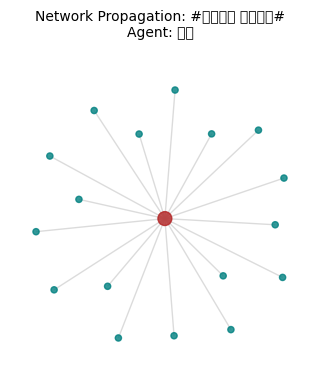

In [33]:
G = plot_network_propagation(data, 
                              title='#名匠出品 必属精品#', 
                              agent='赵林',
                              save_path="diffusion(S3)/zhaolin.png",
                              figsize=(3, 3),
                              dpi=300)

C:\Users\wangy\AppData\Local\Temp\ipykernel_9056\2653058393.py:108: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
C:\Users\wangy\AppData\Local\Temp\ipykernel_9056\2653058393.py:108: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
C:\Users\wangy\AppData\Local\Temp\ipykernel_9056\2653058393.py:108: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
C:\Users\wangy\AppData\Local\Temp\ipykernel_9056\2653058393.py:108: UserWarning: Glyph 35013 (\N{CJK UNIFIED IDEOGRAPH-88C5}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
C:\Users\wangy\AppData\L

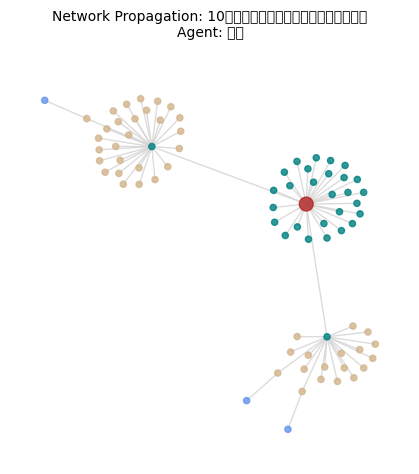

In [36]:
G = plot_network_propagation(data, 
                              title='10大主流装修风格详解，你喜欢哪个范？', 
                              agent='龙海',
                              save_path="diffusion(S3)/longhai.png",
                              figsize=(4, 4),
                              dpi=300)